# **Import Libraries**

In [71]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

print("Libraries Loaded")

Libraries Loaded


# **Upload Dataset**

In [73]:
df = pd.read_csv(r"/content/drive/MyDrive/CNN_model/Soil_Data_Extrapolated.csv")

In [74]:
df.shape

(3112, 58)

# **Remove Duplicate Rows**

In [75]:
print(f"Initial number of rows: {len(df)}")
df.drop_duplicates(inplace=True)
print(f"Number of rows after removing duplicates: {len(df)}")

Initial number of rows: 3112
Number of rows after removing duplicates: 3112


In [76]:
cols_to_drop = [
    'Date',
    'Sample Name',
    'Farm Name',
    'Soil Name'
]

df = df.drop(
    columns=cols_to_drop,
    errors='ignore'
)
df.columns

Index(['Crop Name', 'pH', 'Conductivity', 'Nitrogen', 'Phosphorus',
       'Potassium', 'Boron', 'Copper', 'Ferrous', 'Manganese',
       'Organic Carbon', 'Sulphur', 'Zinc', 'LAI', 'TII', 'ARI', 'RBI', 'CRI',
       'FAI', 'MRI', 'HCI', 'Bi-carbonate', 'Carbonate', 'C/N Ratio',
       'Calcium Carbonate', 'Col410', 'Col435', 'Col460', 'Col485', 'Col510',
       'Col535', 'Col560', 'Col585', 'Col610', 'Col645', 'Col680', 'Col705',
       'Col730', 'Col760', 'Col810', 'Col860', 'Col900', 'Col940', 'S1', 'S2',
       'S3', 'S4', 'Temp', 'Moist', 'EC', 'Ph', 'Nitro', 'Posh', 'Pota'],
      dtype='object')

# **Basic Dataset Information**

In [77]:
print("\nShape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())


Shape:
(3112, 54)

Columns:
Index(['Crop Name', 'pH', 'Conductivity', 'Nitrogen', 'Phosphorus',
       'Potassium', 'Boron', 'Copper', 'Ferrous', 'Manganese',
       'Organic Carbon', 'Sulphur', 'Zinc', 'LAI', 'TII', 'ARI', 'RBI', 'CRI',
       'FAI', 'MRI', 'HCI', 'Bi-carbonate', 'Carbonate', 'C/N Ratio',
       'Calcium Carbonate', 'Col410', 'Col435', 'Col460', 'Col485', 'Col510',
       'Col535', 'Col560', 'Col585', 'Col610', 'Col645', 'Col680', 'Col705',
       'Col730', 'Col760', 'Col810', 'Col860', 'Col900', 'Col940', 'S1', 'S2',
       'S3', 'S4', 'Temp', 'Moist', 'EC', 'Ph', 'Nitro', 'Posh', 'Pota'],
      dtype='object')

Data Types:
Crop Name             object
pH                   float64
Conductivity         float64
Nitrogen             float64
Phosphorus           float64
Potassium            float64
Boron                float64
Copper               float64
Ferrous              float64
Manganese            float64
Organic Carbon       float64
Sulphur              float64


In [91]:
crop_sample_counts = df['Crop_Name'].value_counts()
print(crop_sample_counts)

Crop_Name
Castor     432
Papaya     429
Brinjal    424
Cumin      402
Guava      386
Name: count, dtype: int64


In [78]:
df.head()

,Crop Name,pH,Conductivity,Nitrogen,Phosphorus,Potassium,Boron,Copper,Ferrous,Manganese,...,S2,S3,S4,Temp,Moist,EC,Ph,Nitro,Posh,Pota
0,Guava,7.39,384.0,195.10,45.0,209.17,0.76,0.63,5.08,6.37,...,0,0,300.0,25.5,28.40,384.0,7.39,24.0,34.0,85.0
1,Guava,7.76,383.0,195.10,45.0,209.17,0.76,0.63,5.08,6.37,...,0,0,262.0,23.7,31.10,383.0,7.76,24.0,33.0,84.0
2,Guava,7.83,306.5,195.10,45.0,209.17,0.76,0.63,5.08,6.37,...,0,0,265.5,28.2,22.20,306.5,7.83,21.0,28.0,71.0
3,Guava,7.88,333.0,195.10,45.0,209.17,0.76,0.63,5.08,6.37,...,0,0,258.0,26.1,29.50,333.0,7.88,22.0,30.0,76.0
4,Guava,7.72,360.0,194.26,45.0,247.65,0.76,0.62,5.13,6.49,...,0,0,326.0,28.2,25.15,360.0,7.72,23.0,32.0,80.0


# **Handle Missing Values**

In [79]:
num_cols = df.select_dtypes(
    include=np.number
).columns

imputer = SimpleImputer(
    strategy="median"
)

df[num_cols] = imputer.fit_transform(
    df[num_cols]
)

print("Numeric missing values handled")

Numeric missing values handled


In [80]:
cat_cols = df.select_dtypes(
    exclude=np.number
).columns

for col in cat_cols:

    df[col].fillna(
        df[col].mode()[0],
        inplace=True
    )

/tmp/ipykernel_2050/444975211.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(


# **Clean Column Names**

In [81]:
df.columns = (
    df.columns
    .str.strip()
    .str.replace(" ","_")
)

print(df.columns)

Index(['Crop_Name', 'pH', 'Conductivity', 'Nitrogen', 'Phosphorus',
       'Potassium', 'Boron', 'Copper', 'Ferrous', 'Manganese',
       'Organic_Carbon', 'Sulphur', 'Zinc', 'LAI', 'TII', 'ARI', 'RBI', 'CRI',
       'FAI', 'MRI', 'HCI', 'Bi-carbonate', 'Carbonate', 'C/N_Ratio',
       'Calcium_Carbonate', 'Col410', 'Col435', 'Col460', 'Col485', 'Col510',
       'Col535', 'Col560', 'Col585', 'Col610', 'Col645', 'Col680', 'Col705',
       'Col730', 'Col760', 'Col810', 'Col860', 'Col900', 'Col940', 'S1', 'S2',
       'S3', 'S4', 'Temp', 'Moist', 'EC', 'Ph', 'Nitro', 'Posh', 'Pota'],
      dtype='object')


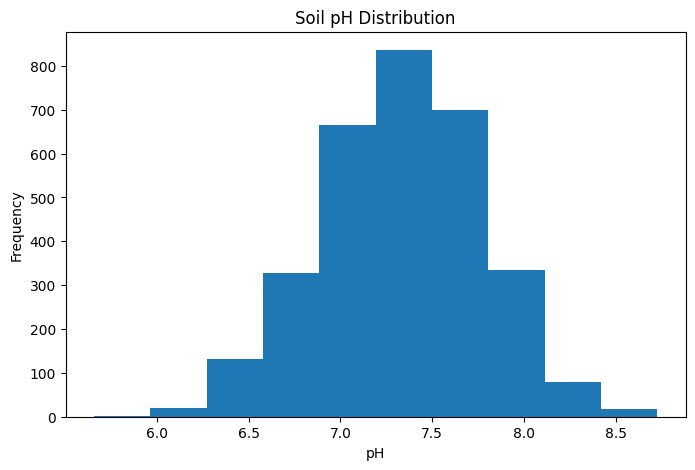

In [82]:
plt.figure(figsize=(8,5))

plt.hist(
    df["pH"],
    bins=10
)

plt.title("Soil pH Distribution")

plt.xlabel("pH")

plt.ylabel("Frequency")

plt.show()

# **Outlier Detection**

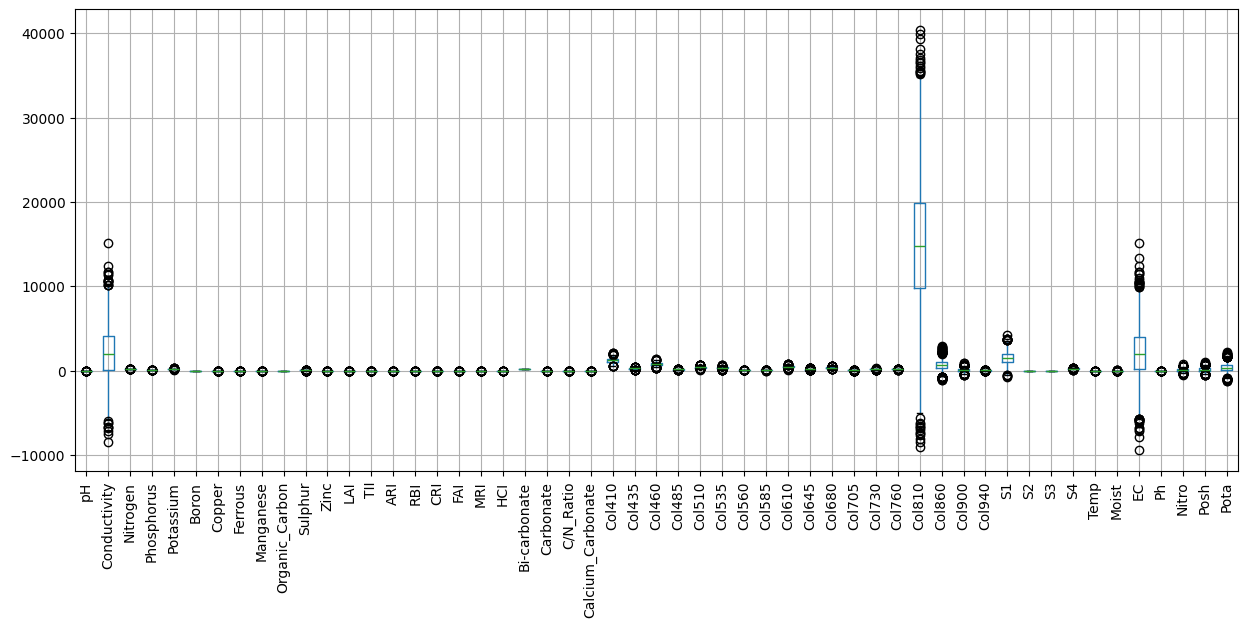

In [83]:
numeric = df.select_dtypes(
    include=np.number
)

plt.figure(
    figsize=(15,6)
)

numeric.boxplot()

plt.xticks(
    rotation=90
)

plt.show()

# **Remove Extreme Outliers**

In [84]:
for col in numeric.columns:

    Q1=df[col].quantile(.25)

    Q3=df[col].quantile(.75)

    IQR=Q3-Q1

    lower=Q1-1.5*IQR

    upper=Q3+1.5*IQR

    df=df[
        (df[col]>=lower)&
        (df[col]<=upper)
    ]

print(df.shape)

(2073, 54)


# **Feature Statistics**

In [85]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
pH,2073.0,7.333837,4.259347e-01,6.153195,7.046344,7.340000,7.635830,8.513442
Conductivity,2073.0,2200.137864,2.918960e+03,-5881.749703,231.012426,2105.387411,4246.157285,10025.736040
Nitrogen,2073.0,195.093498,6.330583e-01,193.343157,194.657986,195.100000,195.506891,196.778967
Phosphorus,2073.0,45.347733,1.943128e+00,39.986153,44.030319,45.221755,46.655515,50.700418
Potassium,2073.0,213.930584,1.779543e+01,165.075300,202.090144,213.116278,225.966214,263.571806
Boron,2073.0,0.760000,8.106584e-15,0.760000,0.760000,0.760000,0.760000,0.760000
Copper,2073.0,0.634423,2.790272e-02,0.559934,0.615693,0.633061,0.653364,0.710148
Ferrous,2073.0,5.100375,1.338884e-01,4.733164,5.009245,5.094949,5.191636,5.463132
Manganese,2073.0,6.384536,4.299921e-02,6.270588,6.355765,6.382702,6.414114,6.500470
Organic_Carbon,2073.0,0.530000,2.065513e-14,0.530000,0.530000,0.530000,0.530000,0.530000


# **Correlation Heatmap**

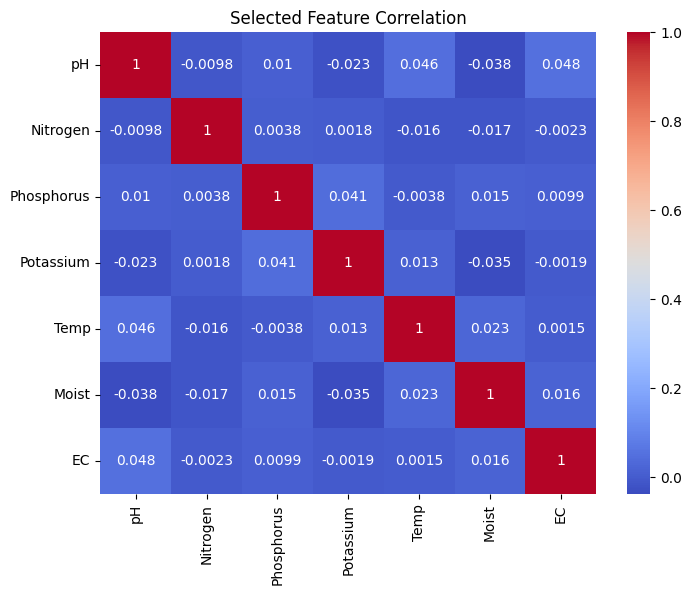

In [86]:
selected = [
    'pH',
    'Nitrogen',
    'Phosphorus',
    'Potassium',
    'Temp',
    'Moist',
    'EC'
]

corr = df[selected].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Selected Feature Correlation")

plt.show()

# **Normalize Numeric Features**

In [87]:
scaler = StandardScaler()

cols = df.select_dtypes(
    include=np.number
).columns

df[cols]=scaler.fit_transform(
    df[cols]
)

print("Normalization Done")

Normalization Done


# **Final Datasets Check**

In [88]:
print(df.shape)

df.head()

(2073, 54)


,Crop_Name,pH,Conductivity,Nitrogen,Phosphorus,Potassium,Boron,Copper,Ferrous,Manganese,...,S2,S3,S4,Temp,Moist,EC,Ph,Nitro,Posh,Pota
2,Guava,1.165161,-0.648894,0.010273,-0.178999,-0.267582,1.110223e-16,-0.158559,-0.152219,-0.338124,...,0.0,0.0,0.156869,1.086234,-0.952075,-0.624518,1.190085,-0.623986,-0.655539,-0.620834
3,Guava,1.282579,-0.639813,0.010273,-0.178999,-0.267582,1.110223e-16,-0.158559,-0.152219,-0.338124,...,0.0,0.0,-0.086664,-1.223471,1.236474,-0.614983,1.308432,-0.616928,-0.645071,-0.610068
4,Guava,0.906843,-0.630561,-1.316939,-0.178999,1.895293,1.110223e-16,-0.517033,0.221317,2.453298,...,0.0,0.0,2.121367,1.086234,-0.067662,-0.605269,0.929722,-0.609870,-0.634602,-0.601455
5,Brinjal,-0.713514,-0.640327,0.010273,-0.178999,-0.267582,1.110223e-16,-0.158559,-0.152219,-0.338124,...,0.0,0.0,0.562757,1.416192,0.456990,-0.615523,-0.703468,-0.616928,-0.645071,-0.611145
8,Brinjal,1.446963,-0.653006,0.010273,-0.178999,-0.267582,1.110223e-16,-0.158559,-0.152219,-0.338124,...,0.0,0.0,-0.151606,0.976248,-1.401777,-0.628835,1.474118,-0.631044,-0.660774,-0.625140


# **Expert Clean Dataset**

In [93]:
df.to_csv(
    r"/content/drive/MyDrive/CNN_model/clean_soil_datasets.csv",
    index=False
)

print("Saved")

Saved
